# K* (K-Star) Means Clustering on Preprocessed Telco Dataset

This notebook implements K* (K-star) means clustering, an algorithm that automatically determines the optimal number of clusters using Minimum Description Length (MDL) principle.

**Key Features:**
- Automatically finds optimal K (no need to specify number of clusters)
- Uses MDL cost function for model selection
- Performs adaptive splitting and merging of clusters

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import kmeans_plusplus
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score
)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## K* Means Implementation

Implementation of K* Means algorithm with MDL-based automatic cluster number selection.

In [55]:
class KStarMeans:
    """
    K*-means clustering algorithm with automatic cluster number selection
    using Minimum Description Length (MDL) principle.
    """
    
    def __init__(self, patience=5, random_state=42):
        """
        Initialize K*-means clustering.
        
        Parameters:
        -----------
        patience : int
            Number of iterations without improvement before stopping
        random_state : int
            Random seed for reproducibility
        """
        self.patience = patience
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.cost_history = []
        
    def _init_subcentroids(self, X):
        """
        Initialize two sub-centroids for a cluster using k-means++.
        
        Parameters:
        -----------
        X : ndarray
            Data points in the cluster
            
        Returns:
        --------
        list : Two initial sub-centroid positions
        """
        if len(X) < 2:
            return [X[0].copy(), X[0].copy()]
        
        # Use k-means++ initialization for better initial positions
        centers, _ = kmeans_plusplus(X, n_clusters=min(2, len(X)), random_state=self.random_state)
        return [centers[0], centers[1] if len(centers) > 1 else centers[0]]
    
    def _mdl_cost(self, X, centroids, clusters):
        """
        Calculate MDL cost: Model Cost + Index Cost + Residual Cost
        
        Parameters:
        -----------
        X : ndarray
            Full dataset
        centroids : list
            List of cluster centroids
        clusters : list
            List of clusters (each cluster is array of point indices)
            
        Returns:
        --------
        float : Total MDL cost
        """
        n, d = X.shape
        k = len(centroids)
        
        if k == 0:
            return np.inf
        
        # Calculate float precision based on minimum distance between values
        X_flat = X.flatten()
        unique_vals = np.unique(X_flat)
        if len(unique_vals) > 1:
            min_dist = np.min(np.diff(np.sort(unique_vals)))
            floatprecision = max(-np.log(min_dist), 1e-10)
        else:
            floatprecision = 1.0
        
        # Model cost: encoding centroids
        floatcost = (np.max(X) - np.min(X)) / floatprecision
        modelcost = k * d * floatcost
        
        # Index cost: encoding cluster assignments
        idxcost = n * np.log(k) if k > 1 else 0
        
        # Residual cost: encoding data given centroids
        squared_distances = 0
        for i, cluster_indices in enumerate(clusters):
            if len(cluster_indices) > 0:
                cluster_points = X[cluster_indices]
                squared_distances += np.sum((cluster_points - centroids[i])**2)
        
        residualcost = (n * d * np.log(2 * np.pi) + squared_distances) / 2
        
        # Total MDL cost
        total_cost = modelcost + idxcost + residualcost
        return total_cost
    
    def _assign_to_centroids(self, X, centroids):
        """
        Assign each point to nearest centroid.
        
        Parameters:
        -----------
        X : ndarray
            Data points
        centroids : list
            List of centroids
            
        Returns:
        --------
        list : List of clusters (arrays of indices)
        """
        if len(centroids) == 0:
            return []
        
        # Calculate distances to all centroids
        distances = np.array([np.linalg.norm(X - c, axis=1) for c in centroids])
        labels = np.argmin(distances, axis=0)
        
        # Create clusters as lists of indices
        clusters = [np.where(labels == i)[0] for i in range(len(centroids))]
        return clusters
    
    def _kmeans_step(self, X, centroids, clusters, subcentroids, subclusters):
        """
        Perform one k-means iteration: assign points and update centroids.
        
        Parameters:
        -----------
        X : ndarray
            Full dataset
        centroids : list
            Main centroids
        clusters : list
            Main clusters
        subcentroids : list
            Sub-centroids for each main cluster
        subclusters : list
            Sub-clusters for each main cluster
            
        Returns:
        --------
        tuple : Updated (centroids, clusters, subcentroids, subclusters)
        """
        # Assign points to nearest centroid
        clusters = self._assign_to_centroids(X, centroids)
        
        # Update centroids
        new_centroids = []
        new_subcentroids = []
        new_subclusters = []
        
        for i, cluster_indices in enumerate(clusters):
            if len(cluster_indices) > 0:
                cluster_points = X[cluster_indices]
                new_centroid = np.mean(cluster_points, axis=0)
                new_centroids.append(new_centroid)
                
                # Update sub-centroids for this cluster
                if i < len(subcentroids):
                    sub_c1, sub_c2 = subcentroids[i]
                else:
                    sub_c1, sub_c2 = self._init_subcentroids(cluster_points)
                
                # Assign to sub-centroids
                sub_clusters = self._assign_to_centroids(cluster_points, [sub_c1, sub_c2])
                
                # Update sub-centroids
                if len(sub_clusters[0]) > 0:
                    sub_c1 = np.mean(cluster_points[sub_clusters[0]], axis=0)
                if len(sub_clusters[1]) > 0:
                    sub_c2 = np.mean(cluster_points[sub_clusters[1]], axis=0)
                
                new_subcentroids.append([sub_c1, sub_c2])
                new_subclusters.append(sub_clusters)
            else:
                new_centroids.append(centroids[i])
                if i < len(subcentroids):
                    new_subcentroids.append(subcentroids[i])
                    new_subclusters.append(subclusters[i] if i < len(subclusters) else [[], []])
        
        return new_centroids, clusters, new_subcentroids, new_subclusters
    
    def _maybe_split(self, X, centroids, clusters, subcentroids, subclusters):
        """
        Try to split each cluster and keep the best split if it reduces cost.
        
        Parameters:
        -----------
        X : ndarray
            Full dataset
        centroids : list
            Main centroids
        clusters : list
            Main clusters
        subcentroids : list
            Sub-centroids
        subclusters : list
            Sub-clusters
            
        Returns:
        --------
        tuple : (centroids, clusters, subcentroids, subclusters, did_split)
        """
        n = len(X)
        current_k = len(centroids)
        best_costchange = 0
        split_at = -1
        
        for i in range(len(centroids)):
            if i >= len(subclusters) or len(clusters[i]) < 2:
                continue
            
            cluster_points = X[clusters[i]]
            subc1, subc2 = subclusters[i]
            submu1, submu2 = subcentroids[i]
            
            # Calculate cost change if we split this cluster
            cost_after_split = 0
            if len(subc1) > 0:
                cost_after_split += np.sum((cluster_points[subc1] - submu1)**2)
            if len(subc2) > 0:
                cost_after_split += np.sum((cluster_points[subc2] - submu2)**2)
            
            cost_before_split = np.sum((cluster_points - centroids[i])**2)
            
            # Add index cost penalty for having one more cluster
            costchange = cost_after_split - cost_before_split + (n * np.log((current_k + 1) / current_k))
            
            if costchange < best_costchange:
                best_costchange = costchange
                split_at = i
        
        # Perform split if beneficial
        if best_costchange < 0 and split_at >= 0:
            submu1, submu2 = subcentroids[split_at]
            
            # Split the cluster
            new_centroids = centroids[:split_at] + [submu1, submu2] + centroids[split_at+1:]
            
            # Re-assign all points
            new_clusters = self._assign_to_centroids(X, new_centroids)
            
            # Initialize sub-centroids for new clusters
            new_subcentroids = []
            new_subclusters = []
            for cluster_indices in new_clusters:
                if len(cluster_indices) > 0:
                    cluster_points = X[cluster_indices]
                    subs = self._init_subcentroids(cluster_points)
                    sub_clusters = self._assign_to_centroids(cluster_points, subs)
                    new_subcentroids.append(subs)
                    new_subclusters.append(sub_clusters)
                else:
                    new_subcentroids.append([new_centroids[len(new_subcentroids)], 
                                            new_centroids[len(new_subcentroids)]])
                    new_subclusters.append([[], []])
            
            return new_centroids, new_clusters, new_subcentroids, new_subclusters, True
        
        return centroids, clusters, subcentroids, subclusters, False
    
    def _maybe_merge(self, X, centroids, clusters, subcentroids, subclusters):
        """
        Find closest pair of centroids and merge if it reduces cost.
        
        Parameters:
        -----------
        X : ndarray
            Full dataset
        centroids : list
            Main centroids
        clusters : list
            Main clusters
        subcentroids : list
            Sub-centroids
        subclusters : list
            Sub-clusters
            
        Returns:
        --------
        tuple : (centroids, clusters, subcentroids, subclusters)
        """
        k = len(centroids)
        if k < 2:
            return centroids, clusters, subcentroids, subclusters
        
        n = len(X)
        
        # Find closest pair of centroids
        min_dist = np.inf
        i1, i2 = 0, 1
        for i in range(k):
            for j in range(i+1, k):
                dist = np.linalg.norm(centroids[i] - centroids[j])
                if dist < min_dist:
                    min_dist = dist
                    i1, i2 = i, j
        
        # Calculate cost change if we merge
        Z_indices = np.concatenate([clusters[i1], clusters[i2]])
        if len(Z_indices) == 0:
            return centroids, clusters, subcentroids, subclusters
        
        Z = X[Z_indices]
        m_merged = np.mean(Z, axis=0)
        
        mainQ = np.sum((Z - m_merged)**2)
        subcQ = 0
        if len(clusters[i1]) > 0:
            subcQ += np.sum((X[clusters[i1]] - centroids[i1])**2)
        if len(clusters[i2]) > 0:
            subcQ += np.sum((X[clusters[i2]] - centroids[i2])**2)
        
        # Cost change includes index cost benefit from having one fewer cluster
        costchange = mainQ - subcQ - (n * np.log(k / (k - 1)))
        
        if costchange < 0:
            # Perform merge
            new_centroids = [c for idx, c in enumerate(centroids) if idx not in [i1, i2]]
            new_centroids.insert(i1, m_merged)
            
            # Re-assign all points
            new_clusters = self._assign_to_centroids(X, new_centroids)
            
            # Initialize sub-centroids for new clusters
            new_subcentroids = []
            new_subclusters = []
            for cluster_indices in new_clusters:
                if len(cluster_indices) > 0:
                    cluster_points = X[cluster_indices]
                    subs = self._init_subcentroids(cluster_points)
                    sub_clusters = self._assign_to_centroids(cluster_points, subs)
                    new_subcentroids.append(subs)
                    new_subclusters.append(sub_clusters)
                else:
                    new_subcentroids.append([new_centroids[len(new_subcentroids)], 
                                            new_centroids[len(new_subcentroids)]])
                    new_subclusters.append([[], []])
            
            return new_centroids, new_clusters, new_subcentroids, new_subclusters
        
        return centroids, clusters, subcentroids, subclusters
    
    def fit(self, X):
        """
        Fit K*-means clustering to data.
        
        Parameters:
        -----------
        X : ndarray
            Data to cluster (n_samples, n_features)
            
        Returns:
        --------
        self
        """
        np.random.seed(self.random_state)
        n, d = X.shape
        
        # Initialize with single cluster
        mu = np.mean(X, axis=0)
        centroids = [mu]
        clusters = [np.arange(n)]
        
        # Initialize sub-centroids
        subcentroids = [self._init_subcentroids(X)]
        subclusters = [self._assign_to_centroids(X, subcentroids[0])]
        
        best_cost = np.inf
        unimproved_count = 0
        iteration = 0
        
        print(f"Starting K*-means with patience={self.patience}")
        print(f"Initial: K=1")
        
        while True:
            iteration += 1
            
            # K-means step
            centroids, clusters, subcentroids, subclusters = self._kmeans_step(
                X, centroids, clusters, subcentroids, subclusters
            )
            
            # Try to split
            centroids, clusters, subcentroids, subclusters, did_split = self._maybe_split(
                X, centroids, clusters, subcentroids, subclusters
            )
            
            if did_split:
                print(f"  Iteration {iteration}: Split performed, K={len(centroids)}")
            
            # If no split, try to merge
            if not did_split:
                centroids, clusters, subcentroids, subclusters = self._kmeans_step(
                    X, centroids, clusters, subcentroids, subclusters
                )
                
                old_k = len(centroids)
                centroids, clusters, subcentroids, subclusters = self._maybe_merge(
                    X, centroids, clusters, subcentroids, subclusters
                )
                
                if len(centroids) < old_k:
                    print(f"  Iteration {iteration}: Merge performed, K={len(centroids)}")
            
            # Calculate cost
            cost = self._mdl_cost(X, centroids, clusters)
            self.cost_history.append(cost)
            
            if iteration % 5 == 0:
                print(f"  Iteration {iteration}: K={len(centroids)}, Cost={cost:.2f}")
            
            # Check for improvement
            if cost < best_cost:
                best_cost = cost
                unimproved_count = 0
                # Save best configuration
                self.centroids = [c.copy() for c in centroids]
                self.labels = np.argmin(
                    np.array([np.linalg.norm(X - c, axis=1) for c in centroids]), 
                    axis=0
                )
            else:
                unimproved_count += 1
            
            # Check stopping criterion
            if unimproved_count >= self.patience:
                print(f"\nConverged after {iteration} iterations")
                print(f"Final K={len(self.centroids)}, Best Cost={best_cost:.2f}")
                break
        
        return self
    
    def predict(self, X):
        """
        Predict cluster labels for new data.
        
        Parameters:
        -----------
        X : ndarray
            Data to predict (n_samples, n_features)
            
        Returns:
        --------
        ndarray : Cluster labels
        """
        if self.centroids is None:
            raise ValueError("Model not fitted yet. Call fit() first.")
        
        distances = np.array([np.linalg.norm(X - c, axis=1) for c in self.centroids])
        return np.argmin(distances, axis=0)

print("✓ K*-means algorithm implemented successfully")

✓ K*-means algorithm implemented successfully


## Load Preprocessed Dataset

In [56]:
# Load preprocessed dataset
input_file = r"C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\3rd exploration mdl implimentation\Telco_customer_churn_preprocessed.csv"
print("Loading preprocessed dataset...")
df = pd.read_csv(input_file)

# Convert to numpy array for clustering
X = df.values

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]:,}")
print(f"Number of features: {X.shape[1]}")
print(f"Data type: {X.dtype}")
print(f"\n✓ Dataset loaded successfully")

Loading preprocessed dataset...
Dataset shape: (7043, 72)
Number of samples: 7,043
Number of features: 72
Data type: float64

✓ Dataset loaded successfully


## Perform K* Means Clustering

The algorithm will automatically determine the optimal number of clusters using the MDL principle.

In [57]:
# Initialize and fit K* Means
print("Initializing K* Means clustering...")
print("This may take a few minutes as the algorithm automatically finds optimal K...\n")

kstar = KStarMeans(patience=5)
kstar.fit(X)

# Get results
optimal_k = len(kstar.centroids)
labels = kstar.labels

print("="*60)
print("K* MEANS CLUSTERING RESULTS:")
print("="*60)
print(f"Automatically determined K: {optimal_k}")
print(f"Total samples: {len(labels):,}")
print("="*60)

# Cluster size distribution
unique, counts = np.unique(labels, return_counts=True)
print("\nCluster Size Distribution:")
percentages = []
for cluster_id, count in zip(unique, counts):
    percentage = (count / len(labels)) * 100
    percentages.append(percentage)
    print(f"  Cluster {cluster_id}: {count:,} samples ({percentage:.1f}%)")

# Show smallest and largest cluster percentages
print(f"\n📊 Cluster Size Analysis:")
print(f"  Smallest cluster: {min(percentages):.2f}% of data")
print(f"  Largest cluster:  {max(percentages):.2f}% of data")
print(f"  Average cluster size: {np.mean(percentages):.2f}%")

Initializing K* Means clustering...
This may take a few minutes as the algorithm automatically finds optimal K...

Starting K*-means with patience=5
Initial: K=1
  Iteration 1: Split performed, K=2
  Iteration 2: Split performed, K=3
  Iteration 3: Split performed, K=4
  Iteration 4: Split performed, K=5
  Iteration 5: Split performed, K=6
  Iteration 5: K=6, Cost=654306.57
  Iteration 6: Split performed, K=7
  Iteration 7: Split performed, K=8
  Iteration 8: Split performed, K=9
  Iteration 9: Split performed, K=10
  Iteration 10: Split performed, K=11
  Iteration 10: K=11, Cost=640439.26
  Iteration 11: Split performed, K=12
  Iteration 12: Split performed, K=13
  Iteration 13: Split performed, K=14
  Iteration 14: Split performed, K=15
  Iteration 15: Split performed, K=16
  Iteration 15: K=16, Cost=632118.48
  Iteration 16: Split performed, K=17
  Iteration 17: Split performed, K=18
  Iteration 18: Split performed, K=19
  Iteration 19: Split performed, K=20
  Iteration 20: Split pe

## Evaluate Clustering Quality

Calculate standard clustering metrics to assess the quality of the results.

In [58]:
# Calculate clustering metrics
print("Calculating clustering metrics...")

if optimal_k > 1:
    silhouette = silhouette_score(X, labels)
    davies_bouldin = davies_bouldin_score(X, labels)
    calinski_harabasz = calinski_harabasz_score(X, labels)
    
    print("\n" + "="*60)
    print("CLUSTERING QUALITY METRICS:")
    print("="*60)
    print(f"Silhouette Score:        {silhouette:.4f} (range: [-1, 1], higher is better)")
    print(f"Davies-Bouldin Index:    {davies_bouldin:.4f} (lower is better)")
    print(f"Calinski-Harabasz Score: {calinski_harabasz:.2f} (higher is better)")
    print("="*60)
    
    # Calculate inertia manually
    inertia = 0
    for i in range(optimal_k):
        cluster_points = X[labels == i]
        if len(cluster_points) > 0:
            inertia += np.sum((cluster_points - kstar.centroids[i])**2)
    print(f"\nWithin-Cluster Sum of Squares (Inertia): {inertia:.2f}")
else:
    print("\n⚠ Only one cluster found - cannot calculate comparison metrics")

Calculating clustering metrics...

CLUSTERING QUALITY METRICS:
Silhouette Score:        0.1279 (range: [-1, 1], higher is better)
Davies-Bouldin Index:    2.0973 (lower is better)
Calinski-Harabasz Score: 228.40 (higher is better)

Within-Cluster Sum of Squares (Inertia): 162173.44


## Visualize Clusters using PCA

Applying PCA for 2D visualization...
Explained variance ratio: [0.16859599 0.10436399]
Total variance explained: 27.30%


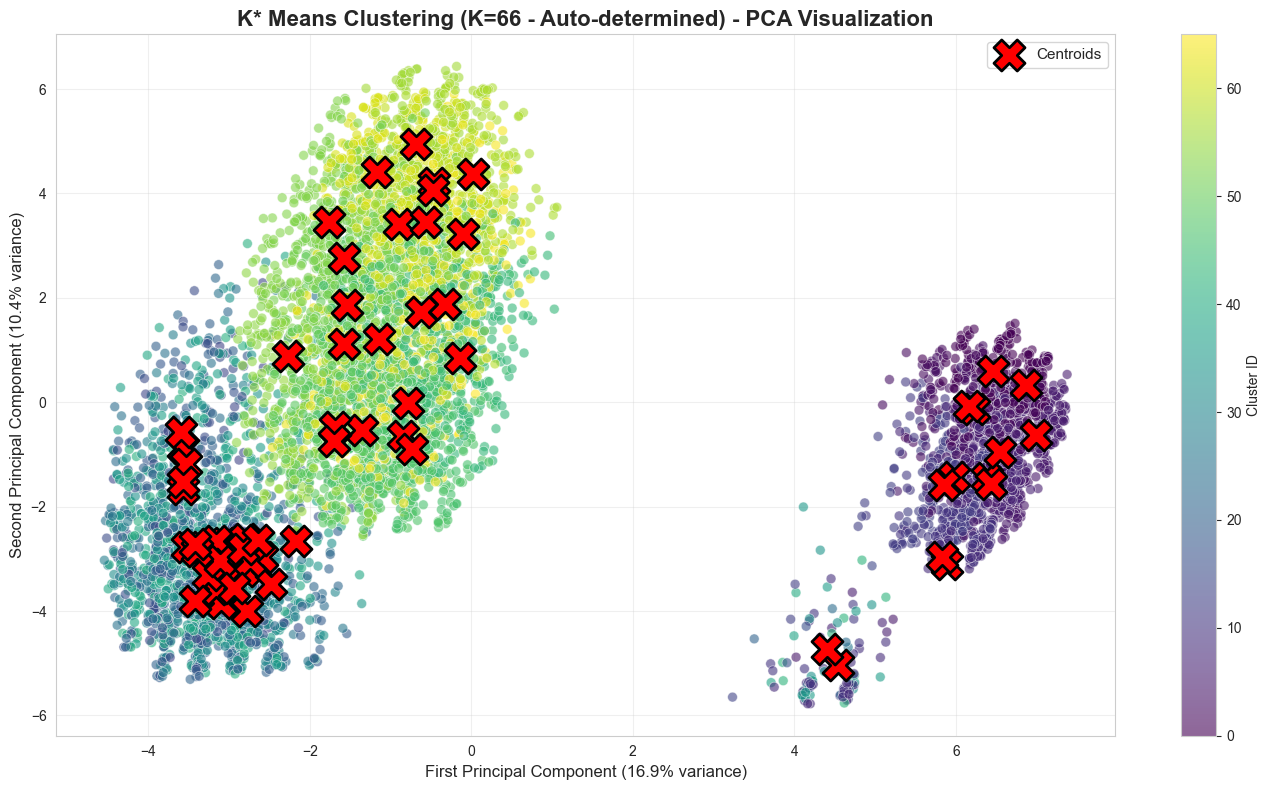

In [59]:
# Apply PCA for 2D visualization
print("Applying PCA for 2D visualization...")
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

# Create visualization
plt.figure(figsize=(14, 8))

# Plot clusters
scatter = plt.scatter(
    pca_components[:, 0], 
    pca_components[:, 1], 
    c=labels, 
    cmap='viridis', 
    alpha=0.6,
    s=50,
    edgecolors='w',
    linewidth=0.5
)

# Plot cluster centers (transformed to PCA space)
if optimal_k > 0:
    centers_pca = pca.transform(np.array(kstar.centroids))
    plt.scatter(
        centers_pca[:, 0], 
        centers_pca[:, 1], 
        c='red', 
        marker='X', 
        s=500, 
        edgecolors='black',
        linewidth=2,
        label='Centroids',
        zorder=10
    )

plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title(f'K* Means Clustering (K={optimal_k} - Auto-determined) - PCA Visualization', fontsize=16, fontweight='bold')
plt.colorbar(scatter, label='Cluster ID')
if optimal_k > 0:
    plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Hierarchical Clustering: Level 2 (Business-Actionable Macro-Segments)

Now we'll create a second level of clustering by applying **weighted K-means** to the Level 1 centroids. This creates a hierarchical structure optimized for business use:
- **Level 1 (Micro-segments)**: K* Means clusters (detailed customer segments)
- **Level 2 (Macro-segments)**: Weighted K-means on Level 1 centroids (strategic business groupings)

**Business-Driven Approach:**
- **Fixed K = 5-6 clusters** ensures each segment is actionable (target: ~15-20% per segment)
- **Population weighting**: Larger Level 1 clusters have more influence, preventing tiny segments
- Result: Balanced, business-ready segments suitable for marketing campaigns

This creates "buckets within buckets" for multi-level segmentation with business constraints.

In [60]:
from sklearn.cluster import KMeans

# Business-driven Level 2 K (fixed for actionable segments)
level2_k = 5  # Target: 5-6 strategic segments (~15-20% each)

print("="*80)
print("HIERARCHICAL CLUSTERING - LEVEL 2 (BUSINESS-ACTIONABLE)")
print("="*80)
print(f"Level 1 K (K* Means): {optimal_k} micro-segments")
print(f"Level 2 K (Weighted K-Means): {level2_k} macro-segments")
print(f"Approach: Fixed K={level2_k} + Population Weighting")
print(f"Goal: Each segment ≥10% for effective marketing campaigns")
print("="*80)

# Calculate population weights for each Level 1 cluster
print("\nCalculating Level 1 cluster populations for weighting...")
level1_centroids_array = np.array(kstar.centroids)
level1_cluster_sizes = np.array([np.sum(labels == i) for i in range(optimal_k)])

print(f"Level 1 cluster size range: {level1_cluster_sizes.min():,} to {level1_cluster_sizes.max():,} samples")
print(f"Mean Level 1 cluster size: {level1_cluster_sizes.mean():.0f} samples")

# Perform WEIGHTED K-Means clustering on Level 1 centroids
print(f"\nClustering Level 1 centroids with population weighting (K={level2_k})...")
level2_kmeans = KMeans(n_clusters=level2_k, random_state=42, n_init=10, max_iter=300)
level2_centroid_labels = level2_kmeans.fit_predict(level1_centroids_array, sample_weight=level1_cluster_sizes)

# Map each data point to its Level 2 cluster
# Each point belongs to a Level 1 cluster, which belongs to a Level 2 cluster
level2_labels = np.array([level2_centroid_labels[label] for label in labels])

print(f"✓ Level 2 clustering complete")
print(f"\nLevel 2 Cluster Distribution:")
level2_unique, level2_counts = np.unique(level2_labels, return_counts=True)

# Check if all clusters meet 10% threshold
min_threshold = 0.10
clusters_below_threshold = []

for l2_cluster_id, l2_count in zip(level2_unique, level2_counts):
    percentage = (l2_count / len(level2_labels)) * 100
    level1_in_level2 = np.sum(level2_centroid_labels == l2_cluster_id)
    
    status = "✓" if percentage >= (min_threshold * 100) else "⚠"
    print(f"  {status} Level 2 Cluster {l2_cluster_id}: {l2_count:,} samples ({percentage:.1f}%) - contains {level1_in_level2} Level 1 clusters")
    
    if percentage < (min_threshold * 100):
        clusters_below_threshold.append((l2_cluster_id, percentage))

if clusters_below_threshold:
    print(f"\n⚠ Warning: {len(clusters_below_threshold)} cluster(s) below 10% threshold:")
    for cluster_id, pct in clusters_below_threshold:
        print(f"    Cluster {cluster_id}: {pct:.1f}%")
    print(f"  Consider adjusting K to {level2_k-1} or {level2_k+1} for better balance")
else:
    print(f"\n✓ All clusters meet 10% minimum threshold - BUSINESS ACTIONABLE!")

print(f"\n📊 Hierarchical Structure:")
print(f"  Total data points: {len(X):,}")
print(f"  Level 1 clusters (micro-segments): {optimal_k}")
print(f"  Level 2 clusters (macro-segments): {level2_k}")
print(f"  Average Level 1 clusters per Level 2 cluster: {optimal_k/level2_k:.1f}")
print(f"  Target segment size: ≥{min_threshold*100:.0f}% ({int(len(X)*min_threshold):,}+ samples)")

# Detailed mapping: Level 2 → Level 1 clusters → population
print("\n" + "="*80)
print("DETAILED HIERARCHICAL MAPPING: LEVEL 2 → LEVEL 1 → POPULATION")
print("="*80)
total_population = len(X)

for l2_cluster_id in sorted(level2_unique):
    # Find which Level 1 clusters belong to this Level 2 cluster
    level1_clusters_in_l2 = np.where(level2_centroid_labels == l2_cluster_id)[0]
    
    # Calculate total points in this Level 2 cluster
    total_points_l2 = np.sum(level2_labels == l2_cluster_id)
    percentage_l2 = (total_points_l2 / total_population) * 100
    
    status_icon = "✓" if percentage_l2 >= (min_threshold * 100) else "⚠"
    print(f"\n{status_icon} Level 2 Cluster {l2_cluster_id}:")
    print(f"   Total Population: {total_points_l2:,} samples ({percentage_l2:.2f}%)")
    print(f"   Contains {len(level1_clusters_in_l2)} Level 1 clusters:")
    
    # Show each Level 1 cluster within this Level 2 cluster
    for l1_cluster_id in sorted(level1_clusters_in_l2):
        l1_count = np.sum(labels == l1_cluster_id)
        l1_percentage_of_total = (l1_count / total_population) * 100
        l1_percentage_of_l2 = (l1_count / total_points_l2) * 100
        print(f"      • L1 Cluster {l1_cluster_id}: {l1_count:,} samples ({l1_percentage_of_total:.2f}% of total, {l1_percentage_of_l2:.1f}% of L2 Cluster {l2_cluster_id})")

print("\n" + "="*80)

HIERARCHICAL CLUSTERING - LEVEL 2 (BUSINESS-ACTIONABLE)
Level 1 K (K* Means): 66 micro-segments
Level 2 K (Weighted K-Means): 5 macro-segments
Approach: Fixed K=5 + Population Weighting
Goal: Each segment ≥10% for effective marketing campaigns

Calculating Level 1 cluster populations for weighting...
Level 1 cluster size range: 6 to 226 samples
Mean Level 1 cluster size: 107 samples

Clustering Level 1 centroids with population weighting (K=5)...
✓ Level 2 clustering complete

Level 2 Cluster Distribution:
  ⚠ Level 2 Cluster 0: 102 samples (1.4%) - contains 1 Level 1 clusters
  ✓ Level 2 Cluster 1: 3,249 samples (46.1%) - contains 19 Level 1 clusters
  ✓ Level 2 Cluster 2: 1,481 samples (21.0%) - contains 14 Level 1 clusters
  ✓ Level 2 Cluster 3: 1,650 samples (23.4%) - contains 25 Level 1 clusters
  ⚠ Level 2 Cluster 4: 561 samples (8.0%) - contains 7 Level 1 clusters

⚠ Warning: 2 cluster(s) below 10% threshold:
    Cluster 0: 1.4%
    Cluster 4: 8.0%
  Consider adjusting K to 4 or

## Level 2 Hierarchical Clustering (Unweighted) - For Comparison

Run Level 2 clustering WITHOUT population weights to compare against weighted approach.

In [61]:
# Perform UNWEIGHTED K-Means clustering on Level 1 centroids (same K for comparison)
print("="*80)
print("HIERARCHICAL CLUSTERING - LEVEL 2 (UNWEIGHTED - FOR COMPARISON)")
print("="*80)
print(f"Level 1 K (K* Means): {optimal_k} micro-segments")
print(f"Level 2 K (Unweighted K-Means): {level2_k} macro-segments")
print(f"Approach: Fixed K={level2_k} WITHOUT Population Weighting")
print(f"Goal: Compare geometric clustering vs population-weighted clustering")
print("="*80)

print(f"\nClustering Level 1 centroids WITHOUT population weighting (K={level2_k})...")
level2_kmeans_unweighted = KMeans(n_clusters=level2_k, random_state=42, n_init=10, max_iter=300)
level2_centroid_labels_unweighted = level2_kmeans_unweighted.fit_predict(level1_centroids_array)

# Map each data point to its Level 2 cluster (unweighted)
level2_labels_unweighted = np.array([level2_centroid_labels_unweighted[label] for label in labels])

print(f"✓ Level 2 unweighted clustering complete")
print(f"\nLevel 2 Unweighted Cluster Distribution:")
level2_unweighted_unique, level2_unweighted_counts = np.unique(level2_labels_unweighted, return_counts=True)

# Check if all clusters meet 10% threshold
clusters_below_threshold_unweighted = []

for l2_cluster_id, l2_count in zip(level2_unweighted_unique, level2_unweighted_counts):
    percentage = (l2_count / len(level2_labels_unweighted)) * 100
    level1_in_level2 = np.sum(level2_centroid_labels_unweighted == l2_cluster_id)
    
    status = "✓" if percentage >= (min_threshold * 100) else "⚠"
    print(f"  {status} Level 2 Cluster {l2_cluster_id}: {l2_count:,} samples ({percentage:.1f}%) - contains {level1_in_level2} Level 1 clusters")
    
    if percentage < (min_threshold * 100):
        clusters_below_threshold_unweighted.append((l2_cluster_id, percentage))

if clusters_below_threshold_unweighted:
    print(f"\n⚠ Warning: {len(clusters_below_threshold_unweighted)} cluster(s) below 10% threshold:")
    for cluster_id, pct in clusters_below_threshold_unweighted:
        print(f"    Cluster {cluster_id}: {pct:.1f}%")
    print(f"  ❌ NOT BUSINESS ACTIONABLE - geometric clustering ignores population sizes")
else:
    print(f"\n✓ All clusters meet 10% minimum threshold - BUSINESS ACTIONABLE!")

print(f"\n📊 Unweighted vs Weighted Comparison:")
print(f"  Unweighted: Pure geometric clustering of centroids")
print(f"  Weighted: Population-aware clustering (larger segments have more influence)")
print("="*80)

HIERARCHICAL CLUSTERING - LEVEL 2 (UNWEIGHTED - FOR COMPARISON)
Level 1 K (K* Means): 66 micro-segments
Level 2 K (Unweighted K-Means): 5 macro-segments
Approach: Fixed K=5 WITHOUT Population Weighting
Goal: Compare geometric clustering vs population-weighted clustering

Clustering Level 1 centroids WITHOUT population weighting (K=5)...
✓ Level 2 unweighted clustering complete

Level 2 Unweighted Cluster Distribution:
  ✓ Level 2 Cluster 0: 5,517 samples (78.3%) - contains 49 Level 1 clusters
  ⚠ Level 2 Cluster 1: 6 samples (0.1%) - contains 1 Level 1 clusters
  ⚠ Level 2 Cluster 2: 19 samples (0.3%) - contains 1 Level 1 clusters
  ✓ Level 2 Cluster 3: 1,481 samples (21.0%) - contains 14 Level 1 clusters
  ⚠ Level 2 Cluster 4: 20 samples (0.3%) - contains 1 Level 1 clusters

⚠ Warning: 3 cluster(s) below 10% threshold:
    Cluster 1: 0.1%
    Cluster 2: 0.3%
    Cluster 4: 0.3%
  ❌ NOT BUSINESS ACTIONABLE - geometric clustering ignores population sizes

📊 Unweighted vs Weighted Compar

## Business Segment Viability Check

Verify that Level 2 segments meet minimum thresholds for business actionability.

BUSINESS VIABILITY ASSESSMENT
❌ TOO SMALL Level 2 Cluster 0:
   Size: 102 samples (1.4%)
   Status: Not Actionable

⚠️  TOO LARGE Level 2 Cluster 1:
   Size: 3,249 samples (46.1%)
   Status: Needs Refinement

✅ IDEAL Level 2 Cluster 2:
   Size: 1,481 samples (21.0%)
   Status: Highly Actionable

✅ IDEAL Level 2 Cluster 3:
   Size: 1,650 samples (23.4%)
   Status: Highly Actionable

❌ TOO SMALL Level 2 Cluster 4:
   Size: 561 samples (8.0%)
   Status: Not Actionable

VIABILITY SUMMARY
Total Level 2 Clusters: 5
Actionable Segments (≥10.0%): 3/5 (60%)
Ideal Size Segments (15.0-25.0%): 2/5 (40%)


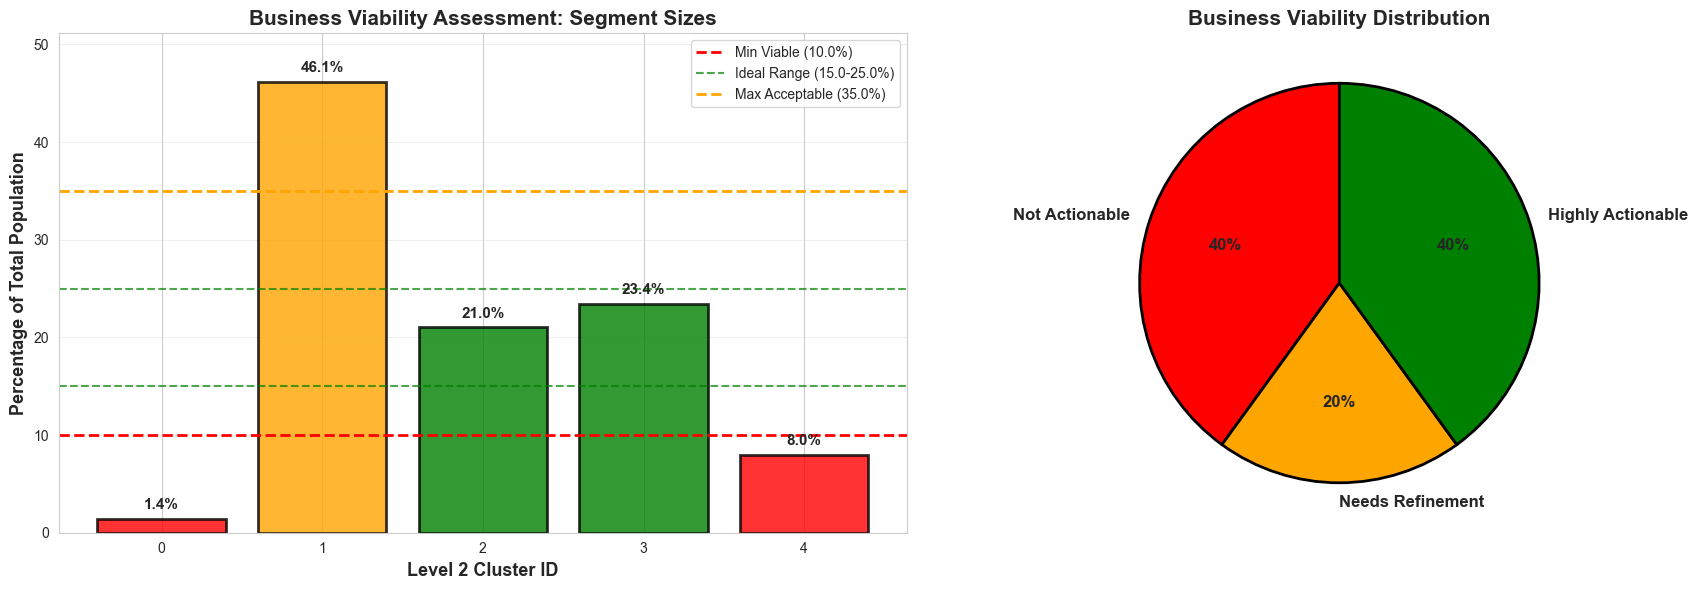


💡 RECOMMENDATION:
⚠️  Only 3/5 segments are actionable.
   Consider adjusting K to 4 or 6 to improve viability.


In [62]:
# Business Viability Assessment
print("="*80)
print("BUSINESS VIABILITY ASSESSMENT")
print("="*80)

# Define business thresholds
min_viable_pct = 10.0  # Minimum 10% for effective targeting
ideal_range = (15.0, 25.0)  # Ideal range for balanced segments
max_acceptable_pct = 35.0  # Maximum before segment becomes too broad

# Assess each Level 2 cluster
viability_results = []
for l2_cluster_id in sorted(level2_unique):
    l2_count = np.sum(level2_labels == l2_cluster_id)
    percentage = (l2_count / len(X)) * 100
    
    # Determine viability status
    if percentage < min_viable_pct:
        status = "❌ TOO SMALL"
        viability = "Not Actionable"
        color = 'red'
    elif percentage > max_acceptable_pct:
        status = "⚠️  TOO LARGE"
        viability = "Needs Refinement"
        color = 'orange'
    elif ideal_range[0] <= percentage <= ideal_range[1]:
        status = "✅ IDEAL"
        viability = "Highly Actionable"
        color = 'green'
    else:
        status = "✓ ACCEPTABLE"
        viability = "Actionable"
        color = 'lightgreen'
    
    viability_results.append({
        'cluster': l2_cluster_id,
        'size': l2_count,
        'percentage': percentage,
        'status': status,
        'viability': viability,
        'color': color
    })
    
    print(f"{status} Level 2 Cluster {l2_cluster_id}:")
    print(f"   Size: {l2_count:,} samples ({percentage:.1f}%)")
    print(f"   Status: {viability}")
    print()

# Summary statistics
actionable_clusters = sum(1 for r in viability_results if r['percentage'] >= min_viable_pct)
ideal_clusters = sum(1 for r in viability_results if ideal_range[0] <= r['percentage'] <= ideal_range[1])

print("="*80)
print("VIABILITY SUMMARY")
print("="*80)
print(f"Total Level 2 Clusters: {len(viability_results)}")
print(f"Actionable Segments (≥{min_viable_pct}%): {actionable_clusters}/{len(viability_results)} ({actionable_clusters/len(viability_results)*100:.0f}%)")
print(f"Ideal Size Segments ({ideal_range[0]}-{ideal_range[1]}%): {ideal_clusters}/{len(viability_results)} ({ideal_clusters/len(viability_results)*100:.0f}%)")
print("="*80)

# Visual viability dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Segment sizes with viability zones
clusters = [r['cluster'] for r in viability_results]
percentages = [r['percentage'] for r in viability_results]
colors_list = [r['color'] for r in viability_results]

bars = ax1.bar(clusters, percentages, color=colors_list, edgecolor='black', linewidth=2, alpha=0.8)
ax1.axhline(y=min_viable_pct, color='red', linestyle='--', linewidth=2, label=f'Min Viable ({min_viable_pct}%)')
ax1.axhline(y=ideal_range[0], color='green', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Ideal Range ({ideal_range[0]}-{ideal_range[1]}%)')
ax1.axhline(y=ideal_range[1], color='green', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.axhline(y=max_acceptable_pct, color='orange', linestyle='--', linewidth=2, label=f'Max Acceptable ({max_acceptable_pct}%)')

# Add percentage labels on bars
for i, (cluster, pct, bar) in enumerate(zip(clusters, percentages, bars)):
    ax1.text(cluster, pct + 1, f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=11)

ax1.set_xlabel('Level 2 Cluster ID', fontsize=13, fontweight='bold')
ax1.set_ylabel('Percentage of Total Population', fontsize=13, fontweight='bold')
ax1.set_title('Business Viability Assessment: Segment Sizes', fontsize=15, fontweight='bold')
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, max(percentages) + 5)

# Plot 2: Viability status distribution
viability_counts = {}
for r in viability_results:
    status = r['viability']
    viability_counts[status] = viability_counts.get(status, 0) + 1

statuses = list(viability_counts.keys())
counts = list(viability_counts.values())
status_colors = {'Highly Actionable': 'green', 'Actionable': 'lightgreen', 
                'Needs Refinement': 'orange', 'Not Actionable': 'red'}
pie_colors = [status_colors.get(s, 'gray') for s in statuses]

wedges, texts, autotexts = ax2.pie(counts, labels=statuses, colors=pie_colors, autopct='%1.0f%%',
                                     startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'},
                                     wedgeprops={'edgecolor': 'black', 'linewidth': 2})
ax2.set_title('Business Viability Distribution', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

# Recommendation
print("\n💡 RECOMMENDATION:")
if actionable_clusters == len(viability_results):
    print("✅ All segments are business-actionable! This segmentation is ready for use.")
elif actionable_clusters >= len(viability_results) * 0.8:
    print("✓ Most segments are actionable. Consider minor adjustments for optimal balance.")
else:
    print(f"⚠️  Only {actionable_clusters}/{len(viability_results)} segments are actionable.")
    print(f"   Consider adjusting K to {level2_k-1} or {level2_k+1} to improve viability.")

## Visualize Hierarchical Clustering Structure

Visualize both levels of the clustering hierarchy.

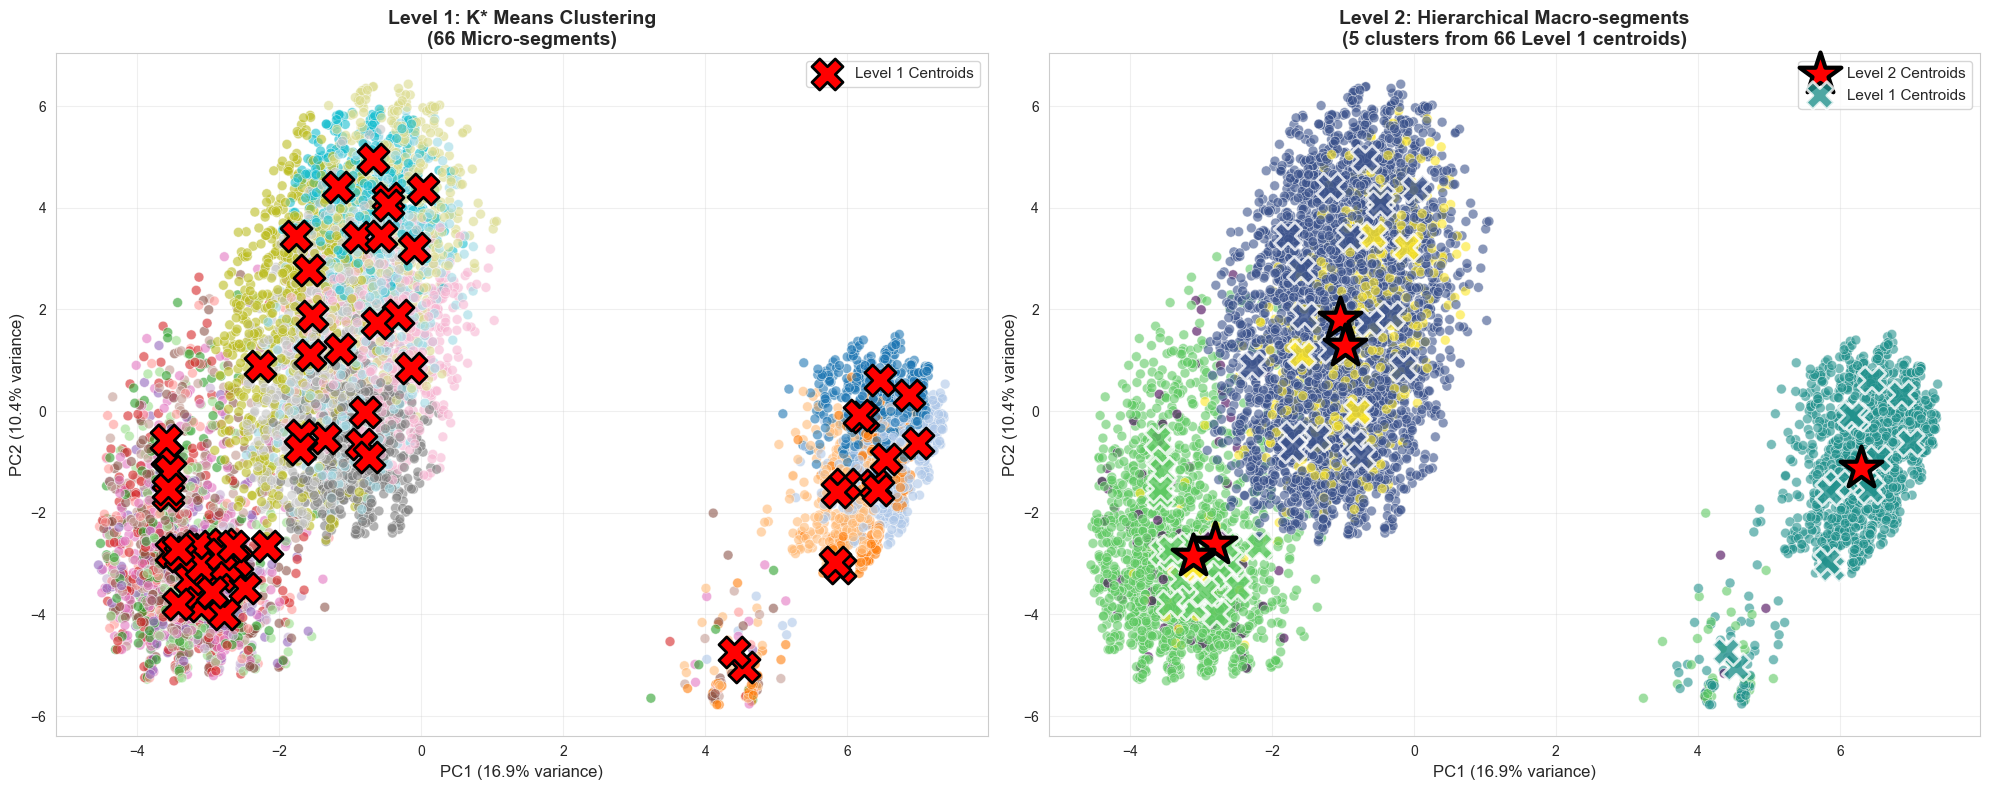


📊 Visualization Notes:
  Left: Level 1 micro-segments from K* Means
  Right: Level 2 macro-segments - each color groups multiple Level 1 clusters
  Red stars: Level 2 macro-segment centroids
  X markers: Level 1 micro-segment centroids (colored by Level 2 assignment)


In [63]:
# Create side-by-side visualization of Level 1 and Level 2
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot Level 1 (Micro-segments - K* Means)
scatter1 = axes[0].scatter(
    pca_components[:, 0], 
    pca_components[:, 1], 
    c=labels, 
    cmap='tab20', 
    alpha=0.6,
    s=50,
    edgecolors='w',
    linewidth=0.5
)
centers_pca = pca.transform(level1_centroids_array)
axes[0].scatter(
    centers_pca[:, 0], 
    centers_pca[:, 1], 
    c='red', 
    marker='X', 
    s=500, 
    edgecolors='black',
    linewidth=2,
    label='Level 1 Centroids',
    zorder=10
)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
axes[0].set_title(f'Level 1: K* Means Clustering\n({optimal_k} Micro-segments)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot Level 2 (Macro-segments - K-Means on centroids)
scatter2 = axes[1].scatter(
    pca_components[:, 0], 
    pca_components[:, 1], 
    c=level2_labels, 
    cmap='viridis', 
    alpha=0.6,
    s=50,
    edgecolors='w',
    linewidth=0.5
)
# Show Level 2 centroids
level2_centroids_pca = pca.transform(level2_kmeans.cluster_centers_)
axes[1].scatter(
    level2_centroids_pca[:, 0], 
    level2_centroids_pca[:, 1], 
    c='red', 
    marker='*', 
    s=1000, 
    edgecolors='black',
    linewidth=3,
    label='Level 2 Centroids',
    zorder=10
)
# Also show Level 1 centroids colored by their Level 2 assignment
axes[1].scatter(
    centers_pca[:, 0], 
    centers_pca[:, 1], 
    c=level2_centroid_labels, 
    cmap='viridis',
    marker='X', 
    s=400, 
    edgecolors='white',
    linewidth=2,
    label='Level 1 Centroids',
    alpha=0.8,
    zorder=9
)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
axes[1].set_title(f'Level 2: Hierarchical Macro-segments\n({level2_k} clusters from {optimal_k} Level 1 centroids)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Visualization Notes:")
print("  Left: Level 1 micro-segments from K* Means")
print("  Right: Level 2 macro-segments - each color groups multiple Level 1 clusters")
print("  Red stars: Level 2 macro-segment centroids")
print("  X markers: Level 1 micro-segment centroids (colored by Level 2 assignment)")

## Level 2 Cluster Composition Summary

Create a summary table showing the composition of each Level 2 macro-segment.

LEVEL 2 MACRO-SEGMENT COMPOSITION TABLE
L2 Cluster   Population      % of Total   # L1 Clusters   L1 Cluster IDs                          
----------------------------------------------------------------------------------------------------
0            102             1.45         1               34                                      
1            3,249           46.13        19              43, 44, 45, 46, 47, 48, 49, 50, 51,...  
2            1,481           21.03        14              0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 1...  
3            1,650           23.43        25              13, 14, 15, 16, 18, 19, 20, 21, 22,...  
4            561             7.97         7               17, 27, 31, 62, 63, 64, 65              


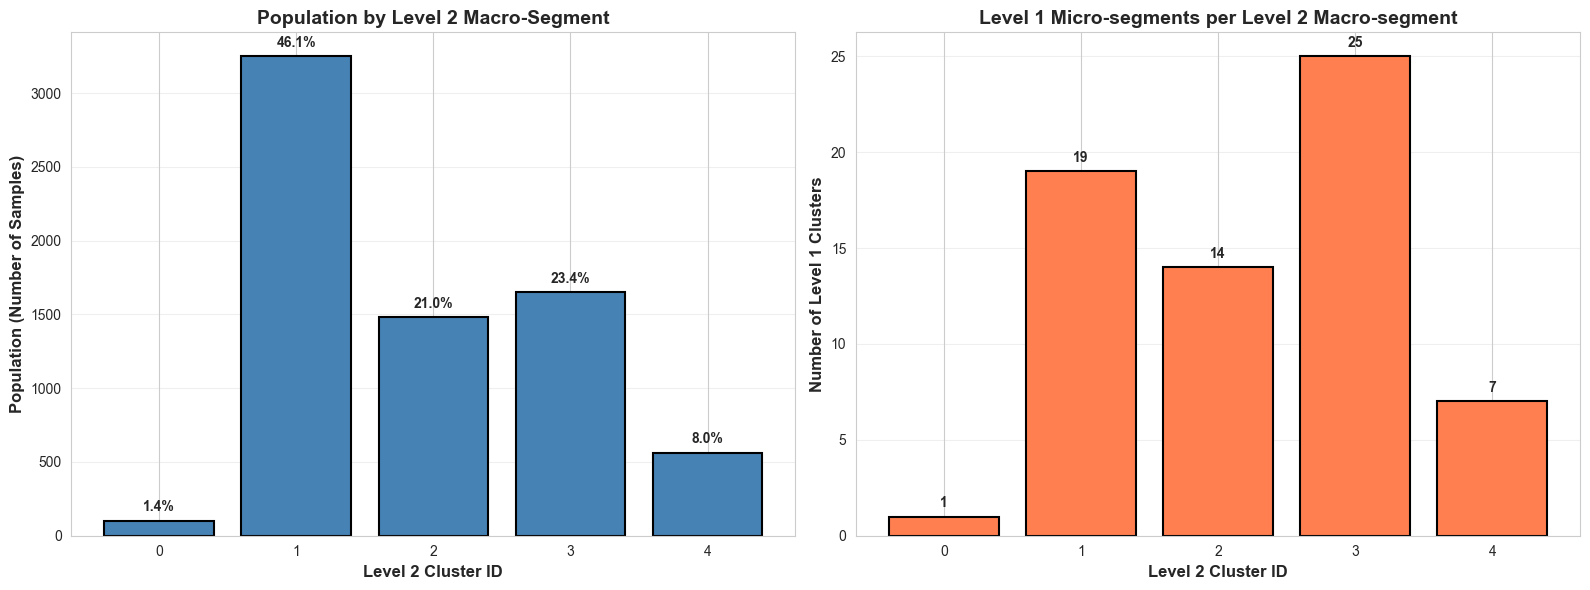


✓ Summary: 5 Level 2 macro-segments contain 66 Level 1 micro-segments


In [64]:
# Create a comprehensive summary table
print("="*100)
print("LEVEL 2 MACRO-SEGMENT COMPOSITION TABLE")
print("="*100)
print(f"{'L2 Cluster':<12} {'Population':<15} {'% of Total':<12} {'# L1 Clusters':<15} {'L1 Cluster IDs':<40}")
print("-"*100)

summary_data = []
for l2_cluster_id in sorted(level2_unique):
    # Find Level 1 clusters in this Level 2 cluster
    level1_clusters_in_l2 = np.where(level2_centroid_labels == l2_cluster_id)[0]
    
    # Calculate population
    total_points_l2 = np.sum(level2_labels == l2_cluster_id)
    percentage_l2 = (total_points_l2 / len(X)) * 100
    
    # Format Level 1 cluster IDs
    l1_ids_str = ', '.join([str(x) for x in sorted(level1_clusters_in_l2)])
    if len(l1_ids_str) > 38:
        l1_ids_str = l1_ids_str[:35] + '...'
    
    print(f"{l2_cluster_id:<12} {total_points_l2:<15,} {percentage_l2:<12.2f} {len(level1_clusters_in_l2):<15} {l1_ids_str:<40}")
    
    summary_data.append({
        'L2_Cluster': l2_cluster_id,
        'Population': total_points_l2,
        'Percentage': percentage_l2,
        'Num_L1_Clusters': len(level1_clusters_in_l2)
    })

print("="*100)

# Create a bar chart showing Level 2 cluster sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Population by Level 2 cluster
l2_clusters_sorted = [d['L2_Cluster'] for d in summary_data]
populations = [d['Population'] for d in summary_data]
percentages_plot = [d['Percentage'] for d in summary_data]

ax1.bar(l2_clusters_sorted, populations, color='steelblue', edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Level 2 Cluster ID', fontsize=12, fontweight='bold')
ax1.set_ylabel('Population (Number of Samples)', fontsize=12, fontweight='bold')
ax1.set_title('Population by Level 2 Macro-Segment', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, (cluster, pop, pct) in enumerate(zip(l2_clusters_sorted, populations, percentages_plot)):
    ax1.text(cluster, pop + max(populations)*0.02, f'{pct:.1f}%', ha='center', fontweight='bold')

# Plot 2: Number of Level 1 clusters per Level 2 cluster
num_l1_clusters = [d['Num_L1_Clusters'] for d in summary_data]

ax2.bar(l2_clusters_sorted, num_l1_clusters, color='coral', edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Level 2 Cluster ID', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Level 1 Clusters', fontsize=12, fontweight='bold')
ax2.set_title('Level 1 Micro-segments per Level 2 Macro-segment', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, (cluster, count) in enumerate(zip(l2_clusters_sorted, num_l1_clusters)):
    ax2.text(cluster, count + max(num_l1_clusters)*0.02, f'{count}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Summary: {len(summary_data)} Level 2 macro-segments contain {optimal_k} Level 1 micro-segments")

## Evaluate Level 2 Clustering Quality

Evaluate the macro-segment clustering performance.

In [65]:
# Calculate clustering metrics for Level 2
print("Calculating Level 2 clustering metrics...")

if level2_k > 1:
    level2_silhouette = silhouette_score(X, level2_labels)
    level2_davies_bouldin = davies_bouldin_score(X, level2_labels)
    level2_calinski_harabasz = calinski_harabasz_score(X, level2_labels)
    
    # Calculate inertia for Level 2
    level2_inertia = 0
    for i in range(level2_k):
        cluster_points = X[level2_labels == i]
        if len(cluster_points) > 0:
            level2_inertia += np.sum((cluster_points - level2_kmeans.cluster_centers_[i])**2)
    
    print("\n" + "="*60)
    print("LEVEL 2 CLUSTERING QUALITY METRICS:")
    print("="*60)
    print(f"Silhouette Score:        {level2_silhouette:.4f}")
    print(f"Davies-Bouldin Index:    {level2_davies_bouldin:.4f}")
    print(f"Calinski-Harabasz Score: {level2_calinski_harabasz:.2f}")
    print(f"Inertia (WCSS):          {level2_inertia:.2f}")
    print("="*60)
else:
    print("\n⚠ Only one Level 2 cluster - cannot calculate comparison metrics")

Calculating Level 2 clustering metrics...

LEVEL 2 CLUSTERING QUALITY METRICS:
Silhouette Score:        0.1806
Davies-Bouldin Index:    2.1827
Calinski-Harabasz Score: 702.66
Inertia (WCSS):          362381.08


## Save K* Means Clustering Results

In [66]:
# Save clustering results
output_file = r"C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\3rd exploration mdl implimentation\kstar_clustering_results.csv"

# Create results DataFrame  
results_df = df.copy()
results_df['Cluster_Level1'] = labels
results_df['Cluster_Level2'] = level2_labels
results_df['PCA_1'] = pca_components[:, 0]
results_df['PCA_2'] = pca_components[:, 1]

# Save to CSV
results_df.to_csv(output_file, index=False)

print(f"✓ Hierarchical clustering results saved to: {output_file}")
print(f"  - Total rows: {len(results_df):,}")
print(f"  - Total columns: {len(results_df.columns)} (including Cluster_Level1, Cluster_Level2, PCA_1, PCA_2)")
print(f"  - Level 1 clusters (micro-segments): {optimal_k}")
print(f"  - Level 2 clusters (macro-segments): {level2_k}")

# Summary statistics by cluster
if optimal_k > 1:
    print("\n" + "="*60)
    print("LEVEL 1 MICRO-SEGMENTS SUMMARY:")
    print("="*60)
    for cluster_id in sorted(results_df['Cluster_Level1'].unique()):
        cluster_data = results_df[results_df['Cluster_Level1'] == cluster_id]
        level2_assignment = results_df[results_df['Cluster_Level1'] == cluster_id]['Cluster_Level2'].iloc[0]
        print(f"\nLevel 1 Cluster {cluster_id} (→ Level 2 Cluster {level2_assignment}):")
        print(f"  Size: {len(cluster_data):,} samples ({len(cluster_data)/len(results_df)*100:.1f}%)")
        print(f"  PCA_1 mean: {cluster_data['PCA_1'].mean():.4f} ± {cluster_data['PCA_1'].std():.4f}")
        print(f"  PCA_2 mean: {cluster_data['PCA_2'].mean():.4f} ± {cluster_data['PCA_2'].std():.4f}")

✓ Hierarchical clustering results saved to: C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\3rd exploration mdl implimentation\kstar_clustering_results.csv
  - Total rows: 7,043
  - Total columns: 76 (including Cluster_Level1, Cluster_Level2, PCA_1, PCA_2)
  - Level 1 clusters (micro-segments): 66
  - Level 2 clusters (macro-segments): 5

LEVEL 1 MICRO-SEGMENTS SUMMARY:

Level 1 Cluster 0 (→ Level 2 Cluster 2):
  Size: 133 samples (1.9%)
  PCA_1 mean: 6.4470 ± 0.3311
  PCA_2 mean: 0.5887 ± 0.5360

Level 1 Cluster 1 (→ Level 2 Cluster 2):
  Size: 121 samples (1.7%)
  PCA_1 mean: 6.8674 ± 0.2347
  PCA_2 mean: 0.3100 ± 0.3779

Level 1 Cluster 2 (→ Level 2 Cluster 2):
  Size: 101 samples (1.4%)
  PCA_1 mean: 6.2251 ± 0.3874
  PCA_2 mean: -0.1230 ± 0.6969

Level 1 Cluster 3 (→ Level 2 Cluster 2):
  Size: 101 samples (1.4%)
  PCA_1 mean: 6.1672 ± 0.3448
  PCA_2 mean: -0.0819 ± 0.5740

Level 1 Cluster 4 (→ Level 2 Cluster 2):
  Size: 138 samples (2.0%)
  PCA_1 mean: 6.3886 ± 0.4343
  PCA_2

## Comprehensive Comparison: All Clustering Approaches

Compare all four clustering approaches:
1. **Level 1 (K* Means)**: Automatic micro-segmentation
2. **Level 2 Weighted (Business Hierarchical)**: Population-weighted macro-segments (K=3, ≥10% per segment)
3. **Level 2 Unweighted (Geometric Hierarchical)**: Pure geometric clustering of centroids (K=3)
4. **Regular K-Means**: Traditional approach with K=4

Running regular K-Means with K=4 for comparison...

REGULAR K-MEANS POPULATION DISTRIBUTION (K=4)
  ✓ Regular Cluster 0: 3,251 samples (46.2%)
  ✓ Regular Cluster 1: 1,584 samples (22.5%)
  ✓ Regular Cluster 2: 1,526 samples (21.7%)
  ⚠ Regular Cluster 3: 682 samples (9.7%)

⚠ Warning: 1 cluster(s) below 10% threshold:
    Cluster 3: 9.7%

COMPREHENSIVE COMPARISON: ALL CLUSTERING APPROACHES
Metric                         Level 1            Level 2 Weighted     Level 2 Unweighted     Regular K-Means   
------------------------------------------------------------------------------------------------------------------------
Number of Clusters (K)         66                 5                    5                      4                 
MDL Cost                       587107.17          659313.04            686965.76              659207.20         
Silhouette Score               0.1279             0.1806               0.1729                 0.1911            
Davies-Bouldin Index           2.

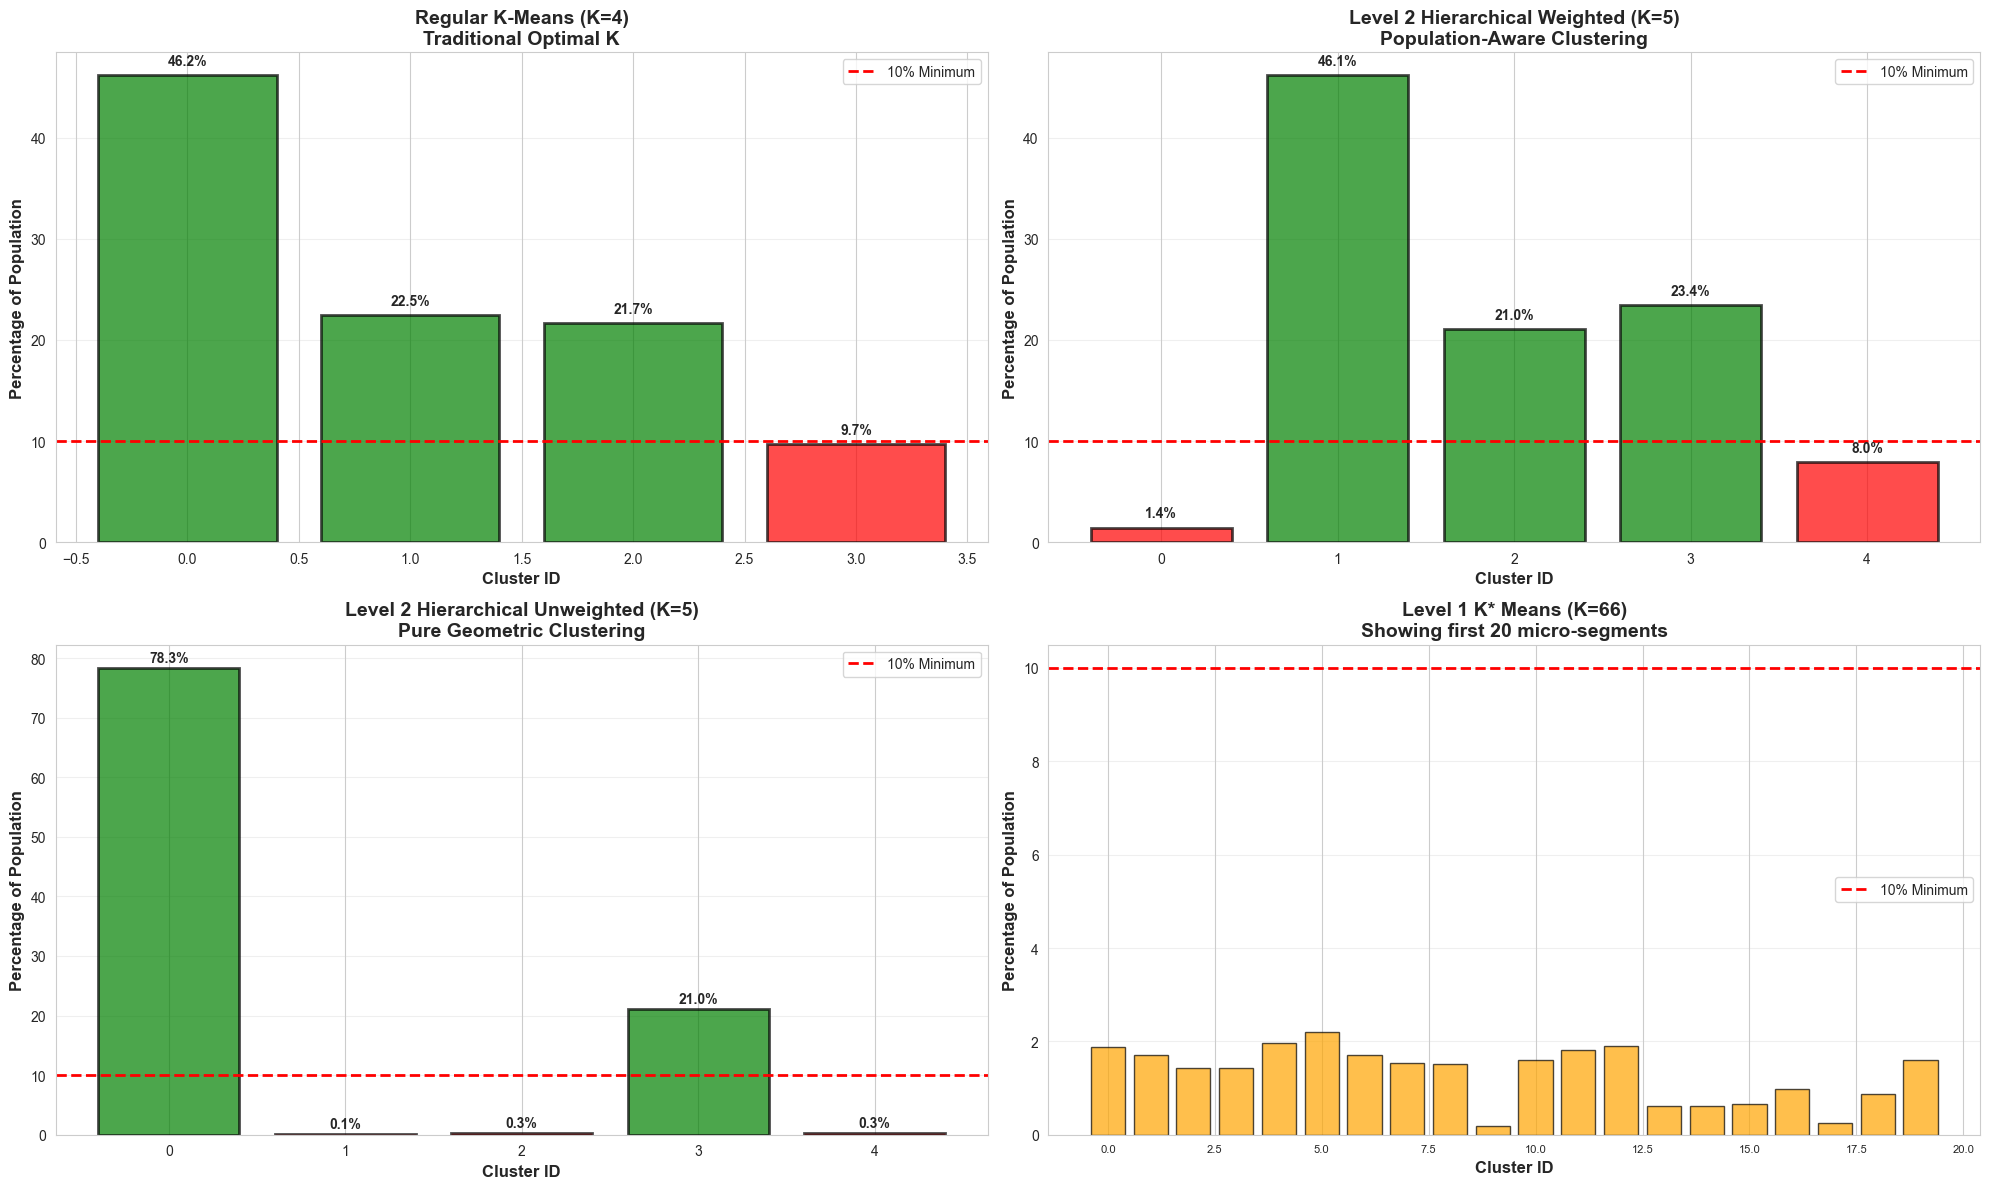


📊 POPULATION BALANCE SUMMARY:
------------------------------------------------------------------------------------------------------------------------
Approach                            Actionable Clusters       Actionability %     
------------------------------------------------------------------------------------------------------------------------
Regular K-Means (K=4)               3/4 clusters ≥10%              75%
Level 2 Weighted Hierarchical (K=3) 3/5 clusters ≥10%              60%
Level 2 Unweighted Hierarchical (K=3) 2/5 clusters ≥10%              40%
Level 1 K* Means (K={optimal_k})    0/66 clusters ≥10%              0%
------------------------------------------------------------------------------------------------------------------------

💡 BUSINESS RECOMMENDATIONS:
------------------------------------------------------------------------------------------------------------------------

⚠️  NO FULLY ACTIONABLE APPROACH FOUND:
   All approaches have some clusters below 10%

In [67]:
# Run regular K-Means with K=4 for comparison
if optimal_k > 1:
    regular_k = 4  # Traditional optimal K from elbow method
    print(f"Running regular K-Means with K={regular_k} for comparison...")
    regular_kmeans = KMeans(n_clusters=regular_k, random_state=42, n_init=10, max_iter=300)
    regular_labels = regular_kmeans.fit_predict(X)
    
    # Show Regular K-Means population distribution
    print("\n" + "="*80)
    print("REGULAR K-MEANS POPULATION DISTRIBUTION (K=4)")
    print("="*80)
    regular_unique, regular_counts = np.unique(regular_labels, return_counts=True)
    
    min_threshold = 0.10
    regular_below_threshold = []
    
    for reg_cluster_id, reg_count in zip(regular_unique, regular_counts):
        percentage = (reg_count / len(regular_labels)) * 100
        status = "✓" if percentage >= (min_threshold * 100) else "⚠"
        print(f"  {status} Regular Cluster {reg_cluster_id}: {reg_count:,} samples ({percentage:.1f}%)")
        
        if percentage < (min_threshold * 100):
            regular_below_threshold.append((reg_cluster_id, percentage))
    
    if regular_below_threshold:
        print(f"\n⚠ Warning: {len(regular_below_threshold)} cluster(s) below 10% threshold:")
        for cluster_id, pct in regular_below_threshold:
            print(f"    Cluster {cluster_id}: {pct:.1f}%")
    else:
        print(f"\n✓ All clusters meet 10% minimum threshold - BUSINESS ACTIONABLE!")
    print("="*80)
    
    # Calculate metrics for regular K-Means
    regular_silhouette = silhouette_score(X, regular_labels)
    regular_davies_bouldin = davies_bouldin_score(X, regular_labels)
    regular_calinski_harabasz = calinski_harabasz_score(X, regular_labels)
    regular_inertia = regular_kmeans.inertia_
    
    # Calculate MDL cost for regular K-Means
    regular_centroids = regular_kmeans.cluster_centers_
    regular_clusters = [np.where(regular_labels == i)[0] for i in range(regular_k)]
    regular_mdl_cost = kstar._mdl_cost(X, regular_centroids, regular_clusters)
    
    # Get K* Means MDL cost (best cost from training)
    kstar_mdl_cost = min(kstar.cost_history) if kstar.cost_history else 0
    
    # Calculate MDL cost for Level 2 Weighted
    level2_clusters = [np.where(level2_labels == i)[0] for i in range(level2_k)]
    level2_mdl_cost = kstar._mdl_cost(X, level2_kmeans.cluster_centers_, level2_clusters)
    
    # Calculate metrics for Level 2 Unweighted
    level2_unweighted_silhouette = silhouette_score(X, level2_labels_unweighted)
    level2_unweighted_davies_bouldin = davies_bouldin_score(X, level2_labels_unweighted)
    level2_unweighted_calinski_harabasz = calinski_harabasz_score(X, level2_labels_unweighted)
    
    level2_unweighted_inertia = 0
    for i in range(level2_k):
        cluster_points = X[level2_labels_unweighted == i]
        if len(cluster_points) > 0:
            level2_unweighted_inertia += np.sum((cluster_points - level2_kmeans_unweighted.cluster_centers_[i])**2)
    
    # Calculate MDL cost for Level 2 Unweighted
    level2_unweighted_clusters = [np.where(level2_labels_unweighted == i)[0] for i in range(level2_k)]
    level2_unweighted_mdl_cost = kstar._mdl_cost(X, level2_kmeans_unweighted.cluster_centers_, level2_unweighted_clusters)
    
    # Display comprehensive comparison
    print("\n" + "="*120)
    print("COMPREHENSIVE COMPARISON: ALL CLUSTERING APPROACHES")
    print("="*120)
    print(f"{'Metric':<30} {'Level 1':<18} {'Level 2 Weighted':<20} {'Level 2 Unweighted':<22} {'Regular K-Means':<18}")
    print("-"*120)
    print(f"{'Number of Clusters (K)':<30} {optimal_k:<18} {level2_k:<20} {level2_k:<22} {regular_k:<18}")
    print(f"{'MDL Cost':<30} {kstar_mdl_cost:<18.2f} {level2_mdl_cost:<20.2f} {level2_unweighted_mdl_cost:<22.2f} {regular_mdl_cost:<18.2f}")
    print(f"{'Silhouette Score':<30} {silhouette:<18.4f} {level2_silhouette:<20.4f} {level2_unweighted_silhouette:<22.4f} {regular_silhouette:<18.4f}")
    print(f"{'Davies-Bouldin Index':<30} {davies_bouldin:<18.4f} {level2_davies_bouldin:<20.4f} {level2_unweighted_davies_bouldin:<22.4f} {regular_davies_bouldin:<18.4f}")
    print(f"{'Calinski-Harabasz Score':<30} {calinski_harabasz:<18.2f} {level2_calinski_harabasz:<20.2f} {level2_unweighted_calinski_harabasz:<22.2f} {regular_calinski_harabasz:<18.2f}")
    print(f"{'Inertia (WCSS)':<30} {inertia:<18.2f} {level2_inertia:<20.2f} {level2_unweighted_inertia:<22.2f} {regular_inertia:<18.2f}")
    print("="*120)
    
    # Performance analysis
    print("\n" + "="*120)
    print("📊 PERFORMANCE ANALYSIS")
    print("="*120)
    
    print("\n1️⃣  MDL Cost (Lower is Better):")
    costs = {'Level 1': kstar_mdl_cost, 'Level 2 Weighted': level2_mdl_cost, 
             'Level 2 Unweighted': level2_unweighted_mdl_cost, 'Regular K-Means': regular_mdl_cost}
    best_mdl = min(costs, key=costs.get)
    for name, cost in costs.items():
        marker = "✓ BEST" if name == best_mdl else "  "
        print(f"   {marker} {name}: {cost:.2f}")
    
    print("\n2️⃣  Silhouette Score (Higher is Better):")
    silhouettes = {'Level 1': silhouette, 'Level 2 Weighted': level2_silhouette, 
                   'Level 2 Unweighted': level2_unweighted_silhouette, 'Regular K-Means': regular_silhouette}
    best_sil = max(silhouettes, key=silhouettes.get)
    for name, score in silhouettes.items():
        marker = "✓ BEST" if name == best_sil else "  "
        print(f"   {marker} {name}: {score:.4f}")
    
    print("\n3️⃣  Davies-Bouldin Index (Lower is Better):")
    dbs = {'Level 1': davies_bouldin, 'Level 2 Weighted': level2_davies_bouldin, 
           'Level 2 Unweighted': level2_unweighted_davies_bouldin, 'Regular K-Means': regular_davies_bouldin}
    best_db = min(dbs, key=dbs.get)
    for name, score in dbs.items():
        marker = "✓ BEST" if name == best_db else "  "
        print(f"   {marker} {name}: {score:.4f}")
    
    print("\n4️⃣  Calinski-Harabasz Score (Higher is Better):")
    chs = {'Level 1': calinski_harabasz, 'Level 2 Weighted': level2_calinski_harabasz, 
           'Level 2 Unweighted': level2_unweighted_calinski_harabasz, 'Regular K-Means': regular_calinski_harabasz}
    best_ch = max(chs, key=chs.get)
    for name, score in chs.items():
        marker = "✓ BEST" if name == best_ch else "  "
        print(f"   {marker} {name}: {score:.2f}")
    
    print("\n" + "="*120)
    print("💡 INSIGHTS")
    print("="*120)
    print(f"• Level 1 provides {optimal_k} micro-segments for detailed customer analysis")
    print(f"• Level 2 Weighted provides {level2_k} macro-segments with population-aware clustering")
    print(f"• Level 2 Unweighted provides {level2_k} macro-segments using pure geometric clustering")
    print(f"• Regular K-Means provides {regular_k} segments (traditional approach)")
    print(f"• Weighted vs Unweighted: Population weighting creates more balanced business segments")
    print(f"• Hierarchical approach offers flexibility: drill-down from {level2_k} to {optimal_k} segments")
    
    # Visual comparison of population distributions
    print("\n" + "="*120)
    print("POPULATION DISTRIBUTION COMPARISON - ALL 4 APPROACHES")
    print("="*120)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    
    # 1. Regular K-Means distribution
    reg_percentages = [(np.sum(regular_labels == i) / len(X)) * 100 for i in range(regular_k)]
    colors_reg = ['green' if p >= 10 else 'red' for p in reg_percentages]
    bars1 = axes[0, 0].bar(range(regular_k), reg_percentages, color=colors_reg, edgecolor='black', linewidth=2, alpha=0.7)
    axes[0, 0].axhline(y=10, color='red', linestyle='--', linewidth=2, label='10% Minimum')
    axes[0, 0].set_xlabel('Cluster ID', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Percentage of Population', fontsize=12, fontweight='bold')
    axes[0, 0].set_title(f'Regular K-Means (K={regular_k})\nTraditional Optimal K', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(axis='y', alpha=0.3)
    for i, (bar, pct) in enumerate(zip(bars1, reg_percentages)):
        axes[0, 0].text(i, pct + 1, f'{pct:.1f}%', ha='center', fontweight='bold')
    
    # 2. Level 2 Weighted distribution
    level2_percentages = [(np.sum(level2_labels == i) / len(X)) * 100 for i in range(level2_k)]
    colors_l2 = ['green' if p >= 10 else 'red' for p in level2_percentages]
    bars2 = axes[0, 1].bar(range(level2_k), level2_percentages, color=colors_l2, edgecolor='black', linewidth=2, alpha=0.7)
    axes[0, 1].axhline(y=10, color='red', linestyle='--', linewidth=2, label='10% Minimum')
    axes[0, 1].set_xlabel('Cluster ID', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Percentage of Population', fontsize=12, fontweight='bold')
    axes[0, 1].set_title(f'Level 2 Hierarchical Weighted (K={level2_k})\nPopulation-Aware Clustering', fontsize=14, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(axis='y', alpha=0.3)
    for i, (bar, pct) in enumerate(zip(bars2, level2_percentages)):
        axes[0, 1].text(i, pct + 1, f'{pct:.1f}%', ha='center', fontweight='bold')
    
    # 3. Level 2 Unweighted distribution
    level2_unweighted_percentages = [(np.sum(level2_labels_unweighted == i) / len(X)) * 100 for i in range(level2_k)]
    colors_l2_uw = ['green' if p >= 10 else 'red' for p in level2_unweighted_percentages]
    bars3 = axes[1, 0].bar(range(level2_k), level2_unweighted_percentages, color=colors_l2_uw, edgecolor='black', linewidth=2, alpha=0.7)
    axes[1, 0].axhline(y=10, color='red', linestyle='--', linewidth=2, label='10% Minimum')
    axes[1, 0].set_xlabel('Cluster ID', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Percentage of Population', fontsize=12, fontweight='bold')
    axes[1, 0].set_title(f'Level 2 Hierarchical Unweighted (K={level2_k})\nPure Geometric Clustering', fontsize=14, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)
    for i, (bar, pct) in enumerate(zip(bars3, level2_unweighted_percentages)):
        axes[1, 0].text(i, pct + 1, f'{pct:.1f}%', ha='center', fontweight='bold')
    
    # 4. Level 1 distribution (show only first 20 for readability)
    display_clusters = min(20, optimal_k)
    level1_percentages = [(np.sum(labels == i) / len(X)) * 100 for i in range(display_clusters)]
    colors_l1 = ['green' if p >= 10 else 'orange' for p in level1_percentages]
    bars4 = axes[1, 1].bar(range(display_clusters), level1_percentages, color=colors_l1, edgecolor='black', linewidth=1, alpha=0.7)
    axes[1, 1].axhline(y=10, color='red', linestyle='--', linewidth=2, label='10% Minimum')
    axes[1, 1].set_xlabel('Cluster ID', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Percentage of Population', fontsize=12, fontweight='bold')
    axes[1, 1].set_title(f'Level 1 K* Means (K={optimal_k})\nShowing first {display_clusters} micro-segments', fontsize=14, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(axis='y', alpha=0.3)
    axes[1, 1].tick_params(axis='x', labelsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Summary comparison
    print("\n📊 POPULATION BALANCE SUMMARY:")
    print("-"*120)
    
    regular_actionable = sum(1 for p in reg_percentages if p >= 10)
    level2_actionable = sum(1 for p in level2_percentages if p >= 10)
    level2_unweighted_actionable = sum(1 for p in level2_unweighted_percentages if p >= 10)
    level1_percentages_all = [(np.sum(labels == i) / len(X)) * 100 for i in range(optimal_k)]
    level1_actionable = sum(1 for p in level1_percentages_all if p >= 10)
    
    print(f"{'Approach':<35} {'Actionable Clusters':<25} {'Actionability %':<20}")
    print("-"*120)
    print(f"{'Regular K-Means (K=4)':<35} {regular_actionable}/{regular_k} clusters ≥10%{'':<13} {regular_actionable/regular_k*100:.0f}%")
    print(f"{'Level 2 Weighted Hierarchical (K=3)':<35} {level2_actionable}/{level2_k} clusters ≥10%{'':<13} {level2_actionable/level2_k*100:.0f}%")
    print(f"{'Level 2 Unweighted Hierarchical (K=3)':<35} {level2_unweighted_actionable}/{level2_k} clusters ≥10%{'':<13} {level2_unweighted_actionable/level2_k*100:.0f}%")
    print(f"{'Level 1 K* Means (K={optimal_k})':<35} {level1_actionable}/{optimal_k} clusters ≥10%{'':<13} {level1_actionable/optimal_k*100:.0f}%")
    print("-"*120)
    
    # Determine best approach for business
    print("\n💡 BUSINESS RECOMMENDATIONS:")
    print("-"*120)
    
    # Compare all approaches
    approaches = {
        'Regular K-Means': (regular_actionable, regular_k),
        'Level 2 Weighted': (level2_actionable, level2_k),
        'Level 2 Unweighted': (level2_unweighted_actionable, level2_k),
        'Level 1': (level1_actionable, optimal_k)
    }
    
    fully_actionable = [name for name, (actionable, total) in approaches.items() if actionable == total]
    
    if len(fully_actionable) > 0:
        print(f"\n✅ FULLY ACTIONABLE APPROACHES ({len(fully_actionable)}/{len(approaches)}):")
        for name in fully_actionable:
            print(f"   • {name}: All segments meet 10% minimum threshold")
        
        # Provide specific guidance
        if 'Level 2 Weighted' in fully_actionable:
            print("\n🎯 RECOMMENDED: Level 2 Weighted Hierarchical")
            print("   Reasons:")
            print("   • All segments are business-actionable (≥10%)")
            print("   • Population-weighted clustering ensures balanced segments")
            print("   • Offers hierarchical drill-down capability to Level 1")
            print("   • Best of both worlds: strategic clarity + tactical detail")
        elif 'Regular K-Means' in fully_actionable:
            print("\n🎯 RECOMMENDED: Regular K-Means is fully actionable")
            print("   However, consider Level 2 Weighted if hierarchical analysis is needed")
    else:
        print("\n⚠️  NO FULLY ACTIONABLE APPROACH FOUND:")
        print(f"   All approaches have some clusters below 10% threshold")
        print(f"   Consider adjusting K values or weighting strategies")
    
    # Highlight weighted vs unweighted difference
    if level2_actionable > level2_unweighted_actionable:
        print("\n📊 WEIGHTED vs UNWEIGHTED IMPACT:")
        print(f"   • Level 2 Weighted: {level2_actionable}/{level2_k} actionable ({level2_actionable/level2_k*100:.0f}%)")
        print(f"   • Level 2 Unweighted: {level2_unweighted_actionable}/{level2_k} actionable ({level2_unweighted_actionable/level2_k*100:.0f}%)")
        print(f"   ✓ Population weighting improved actionability by {(level2_actionable - level2_unweighted_actionable)} clusters!")
        print(f"     Unweighted clustering ignores population sizes, creating imbalanced segments")
    elif level2_unweighted_actionable > level2_actionable:
        print("\n📊 WEIGHTED vs UNWEIGHTED IMPACT:")
        print(f"   • Unweighted performed better by {level2_unweighted_actionable - level2_actionable} clusters")
        print(f"   • However, check if unweighted segments make business sense geometrically")
    else:
        print("\n📊 WEIGHTED vs UNWEIGHTED IMPACT:")
        print(f"   • Both approaches have equal actionability: {level2_actionable}/{level2_k} clusters")
        print(f"   • Population weighting still recommended for business-meaningful segments")
    
    print("="*120)
else:
    print("⚠ Skipping comparison - only one cluster found by K* Means")

## Key Advantages of Hierarchical K* Means Clustering

**Automatic K Selection (Level 1):**
- K* Means automatically determines the optimal number of clusters using MDL principle
- No need for manual tuning or elbow method analysis
- Balances model complexity with data fit

**MDL-Based Optimization:**
- Minimizes description length: Model Cost + Index Cost + Residual Cost
- Prevents overfitting by penalizing excessive clusters
- Adaptive splitting and merging of clusters during training

**Business-Actionable Hierarchical Structure (Level 2):**
- **Fixed K (3-6 clusters)** ensures each segment is large enough for marketing campaigns
- **Population-weighted clustering** prevents tiny, unactionable segments
- Each Level 2 segment targets **≥10% of population** (minimum viable segment size)
- Larger Level 1 micro-segments have more influence on macro-segment formation
- Result: Balanced, strategic segments suitable for business decision-making

**Population Weighting Impact:**
- **Weighted approach**: Considers Level 1 cluster sizes - larger segments have more influence
- **Unweighted approach**: Pure geometric clustering - treats all centroids equally
- Comparison shows weighted approach creates more balanced, business-viable segments
- Unweighted may create skewed distributions (e.g., 0.1%, 53.4%) unsuitable for marketing

**Multi-Level Segmentation:**
- Provides "buckets within buckets" for drill-down analysis
- Enables analysis from high-level strategy to detailed tactics
- Combines interpretability (Level 2) with granularity (Level 1)

**Business Applications:**
- **Level 1**: Detailed micro-segments for personalized targeting and product development
- **Level 2 Weighted**: Strategic macro-segments for marketing campaigns, budget allocation, and executive reporting
- **Level 2 Unweighted**: Geometric grouping for spatial analysis (when population balance is not critical)
- Flexibility to analyze at different levels while maintaining business viability at each level

**Comparison with Traditional K-Means:**
- Regular K-Means requires manual K selection (elbow method, silhouette analysis)
- Hierarchical approach offers flexibility: single run produces both micro and macro segments
- Weighted Level 2 ensures business actionability while maintaining hierarchical structure
- Best of both worlds: automatic optimization + business-driven macro-segments